# Inventory Structure & Warehouse Profile Analysis

This notebook analyses the physical and operational structure of the spare-parts warehouse.

The objective is to evaluate:
- warehouse inventory distribution
- movement concentration across storage locations
- dimensional and volume characteristics of stored items
- storage-density implications
- UDC/container utilisation
- operational warehouse structure

The analyses provide the operational foundation for the following warehouse automation and tray-allocation evaluations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

OUTPUT_DIR = Path("../outputs/as_is_warehouse_summary")
OUTPUT_DIR.mkdir(exist_ok=True)

part_master = pd.read_csv("../data/part_master.csv")
inventory_status = pd.read_csv("../data/inventory_status.csv")

## Warehouse Structure Dataset

The warehouse structure analysis combines:
- inventory master data
- movement classifications
- dimensional information
- stock quantities
- warehouse locations
- UDC/container references
- physical fields supporting later automation analysis

The objective is to evaluate how inventory is physically distributed within the warehouse environment.

In [3]:
# Combine warehouse master data with current inventory metrics
warehouse_profile = (
    part_master
    .merge(
        inventory_status[
            [
                "Part_ID",
                "Available_Qty",
                "Avg_Weekly_Demand",
                "Demand_CV"
            ]
        ],
        on="Part_ID",
        how="left"
    )
)

# Estimate available inventory value for warehouse prioritisation
warehouse_profile["Estimated_Inventory_Value"] = (
    warehouse_profile["Available_Qty"] *
    warehouse_profile["Unit_Cost_EUR"]
)

warehouse_profile.head()

,Part_ID,Part_Name,Equipment_Family_ID,Equipment_Family,Equipment_Model,Part_Category_ID,Part_Category,Demand_Profile,Criticality,Supplier_ID,Supplier_Region,Unit_Cost_EUR,Storage_Type,Lifecycle_Status,Target_Service_Level,Avg_Weekly_Demand_Seed,ABC_Class,Source_Context,Movement_Class,Movement_Lines_36M,Annual_Lines,Avg_Monthly_Lines,Cumulative_Movement_%,Manual_Location,UDC_Type,Dim_X_mm,Dim_Y_mm,Dim_Z_mm,Unit_Volume_cm3,Max_Dimension_mm,Min_Dimension_mm,Stock_Managed,Avg_Daily_Qty,Lead_Time_Weeks,Safety_Stock_Qty,Reorder_Point_Qty,Max_Stock_Qty,Stock_Qty,Total_Qty_36M,Total_Volume_cm3,Available_Qty,Avg_Weekly_Demand,Demand_CV,Estimated_Inventory_Value
0,TC-CON-0343,Basic Line TC Grease Cartridge,TC,Tyre Changer,Basic Line TC,CON,Consumables & service kits,frequent,Medium,SUP-015,EU,40.87,Bin,Active,0.94,4.141,A,Anonymised/reconstructed warehouse transition ...,A+,473,157.7,13.14,7.47,R-I38,VER,1543,689,68,72293,1543,68,1,2.300,1.4,18,35,48,46,1795,3470064,37,3.000000,1.090197,1512.19
1,VL-CON-0336,Scissor Lift Air Filter,VL,Vehicle Lift,Scissor Lift,CON,Consumables & service kits,frequent,Medium,SUP-004,EU,29.16,Bin,Active,0.94,4.364,A,Anonymised/reconstructed warehouse transition ...,A+,395,131.7,10.97,13.72,R-B17,D,258,91,20,470,258,20,1,1.706,1.0,13,22,38,23,1331,17860,16,3.852564,0.583625,466.56
2,TC-CON-0329,A2024 LL Air Filter,TC,Tyre Changer,A2024 LL,CON,Consumables & service kits,frequent,Medium,SUP-018,EU,43.54,Bin,Active,0.94,3.839,A,Anonymised/reconstructed warehouse transition ...,A+,313,104.3,8.69,18.66,R-E25,B,61,30,42,77,61,30,1,1.272,1.3,13,22,39,23,993,3003,18,3.365385,0.603877,783.72
3,WA-CON-0631,Exact Precision Lubrication Kit,WA,Wheel Aligner,Exact Precision,CON,Consumables & service kits,frequent,Medium,SUP-020,EU,26.96,Bin,Active,0.94,4.334,A,Anonymised/reconstructed warehouse transition ...,A+,231,77.0,6.42,22.31,R-F76,D,177,98,143,2480,177,98,1,0.867,1.3,15,21,32,16,677,79360,19,3.602564,0.587932,512.24
4,TC-CON-0171,Basic Line TC Air Filter,TC,Tyre Changer,Basic Line TC,CON,Consumables & service kits,frequent,Medium,SUP-003,EU,40.68,Bin,Active,0.94,4.441,A,Anonymised/reconstructed warehouse transition ...,A+,227,75.7,6.31,25.90,R-L86,B,135,132,46,820,135,46,1,1.030,1.0,6,12,20,17,804,16400,15,2.929487,1.170425,610.20


## Warehouse Location Distribution

This section evaluates how spare parts are distributed across the manual warehouse structure.

The analysis focuses on:
- SKU distribution
- movement concentration
- inventory concentration
- operational warehouse activity

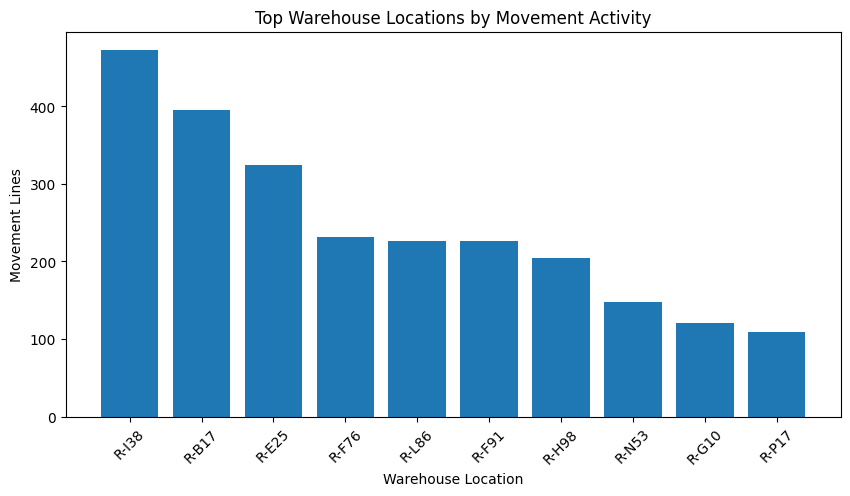

,Manual_Location,Parts,Total_Stock_Qty,Total_Movement_Lines,Total_Inventory_Value
336,R-I38,1,46,473,1512.19
38,R-B17,1,23,395,466.56
174,R-E25,3,29,324,1362.48
241,R-F76,1,16,231,512.24
397,R-L86,1,17,227,610.20
248,R-F91,1,34,227,485.10
319,R-H98,2,23,204,511.47
470,R-N53,2,26,148,1491.11
253,R-G10,1,7,120,524.16
499,R-P17,1,12,109,265.00


In [4]:
location_summary = (
    warehouse_profile
    .groupby("Manual_Location")
    .agg(
        Parts=("Part_ID", "count"),
        Total_Stock_Qty=("Stock_Qty", "sum"),
        Total_Movement_Lines=("Movement_Lines_36M", "sum"),
        Total_Inventory_Value=("Estimated_Inventory_Value", "sum")
    )
    .round(2)
    .reset_index()
    .sort_values("Total_Movement_Lines", ascending=False)
)

plt.figure(figsize=(10,5))

top_locations = location_summary.head(10)

plt.bar(
    top_locations["Manual_Location"],
    top_locations["Total_Movement_Lines"]
)

plt.xticks(rotation=45)
plt.xlabel("Warehouse Location")
plt.ylabel("Movement Lines")
plt.title("Top Warehouse Locations by Movement Activity")

plt.show()

location_summary.head(15)

## Movement Concentration Analysis

Warehouse operational activity is often concentrated within a limited subset of inventory items.

This section evaluates how warehouse movement is distributed across movement classes.

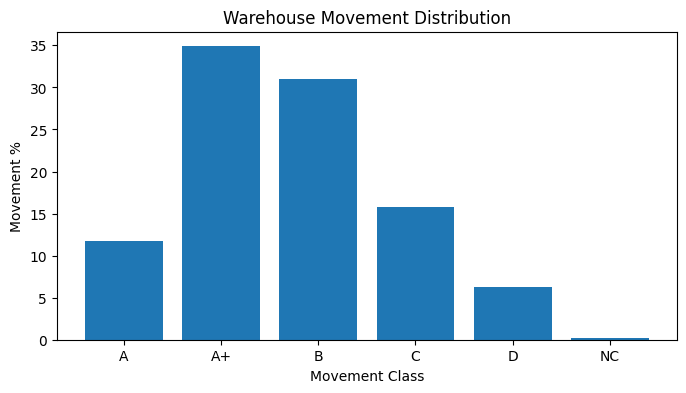

,Movement_Class,Parts,Total_Movement_Lines,Avg_Stock_Qty,Avg_Inventory_Value,Movement_%
0,A,9,742,13.56,314.49,11.73
1,A+,8,2207,23.50,762.18,34.88
2,B,59,1965,13.25,199.74,31.05
3,C,167,1001,9.28,448.06,15.82
4,D,338,397,4.67,575.14,6.27
5,NC,419,16,2.87,1186.94,0.25


In [5]:
movement_profile = (
    warehouse_profile
    .groupby("Movement_Class")
    .agg(
        Parts=("Part_ID", "count"),
        Total_Movement_Lines=("Movement_Lines_36M", "sum"),
        Avg_Stock_Qty=("Stock_Qty", "mean"),
        Avg_Inventory_Value=("Estimated_Inventory_Value", "mean")
    )
    .round(2)
    .reset_index()
)

movement_profile["Movement_%"] = (
    movement_profile["Total_Movement_Lines"] /
    movement_profile["Total_Movement_Lines"].sum() * 100
).round(2)

plt.figure(figsize=(8,4))

plt.bar(
    movement_profile["Movement_Class"],
    movement_profile["Movement_%"]
)

plt.xlabel("Movement Class")
plt.ylabel("Movement %")
plt.title("Warehouse Movement Distribution")

plt.show()

movement_profile

## UDC / Container Structure

The warehouse environment includes multiple handling and storage-unit types.

This section evaluates how inventory is distributed across:
- UDC/container types
- handling structures
- storage categories

This analysis is important because container compatibility directly affects automated warehouse allocation feasibility.

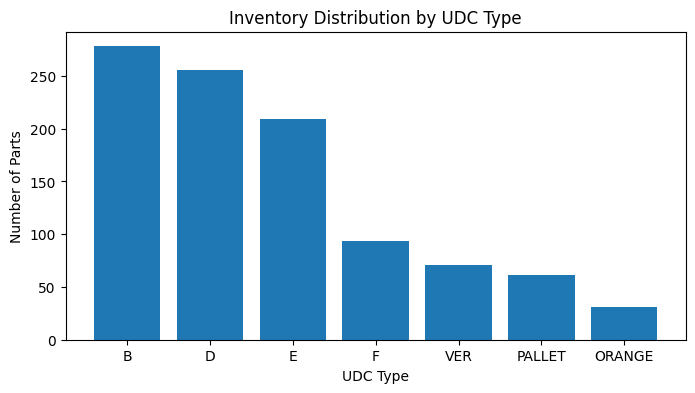

,UDC_Type,Parts,Total_Stock_Qty,Avg_Unit_Volume,Total_Movement_Lines
0,B,278,1642,444.69,1783
1,D,256,1455,2944.24,2492
2,E,209,1118,5994.11,797
3,F,94,525,17240.17,427
6,VER,71,319,60416.77,584
5,PALLET,61,232,288234.25,113
4,ORANGE,31,131,274620.94,132


In [6]:
udc_summary = (
    warehouse_profile
    .groupby("UDC_Type")
    .agg(
        Parts=("Part_ID", "count"),
        Total_Stock_Qty=("Stock_Qty", "sum"),
        Avg_Unit_Volume=("Unit_Volume_cm3", "mean"),
        Total_Movement_Lines=("Movement_Lines_36M", "sum")
    )
    .round(2)
    .reset_index()
    .sort_values("Parts", ascending=False)
)

plt.figure(figsize=(8,4))

plt.bar(
    udc_summary["UDC_Type"],
    udc_summary["Parts"]
)

plt.xlabel("UDC Type")
plt.ylabel("Number of Parts")
plt.title("Inventory Distribution by UDC Type")

plt.show()

udc_summary

## Dimensional & Volume Analysis

This section evaluates the physical characteristics of the spare-parts population.

The objective is to understand:
- dimensional variability
- occupied warehouse volume
- storage-density implications

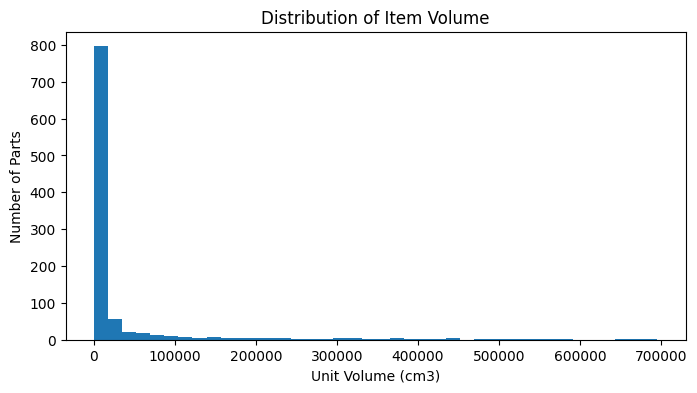

,Dim_X_mm,Dim_Y_mm,Dim_Z_mm,Unit_Volume_cm3,Max_Dimension_mm
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,330.92,247.52,121.99,34135.82,357.39
std,325.74,187.91,143.29,94990.78,316.28
min,20.00,20.00,5.00,3.00,23.00
25%,114.00,118.00,49.00,711.00,138.00
50%,222.50,187.00,88.00,2927.50,245.50
75%,376.25,327.25,132.00,11136.75,397.00
max,1543.00,991.00,886.00,695640.00,1543.00


In [7]:
dimension_summary = (
    warehouse_profile[
        [
            "Dim_X_mm",
            "Dim_Y_mm",
            "Dim_Z_mm",
            "Unit_Volume_cm3",
            "Max_Dimension_mm"
        ]
    ]
    .describe()
    .round(2)
)

plt.figure(figsize=(8,4))

plt.hist(
    warehouse_profile["Unit_Volume_cm3"],
    bins=40
)

plt.xlabel("Unit Volume (cm3)")
plt.ylabel("Number of Parts")
plt.title("Distribution of Item Volume")

plt.show()

dimension_summary

## Inventory Volume Concentration

Warehouse volume occupation is not always aligned with movement intensity or inventory value.

This section evaluates whether:
- low-movement items occupy excessive space
- high-volume items generate limited operational activity
- storage-density opportunities exist

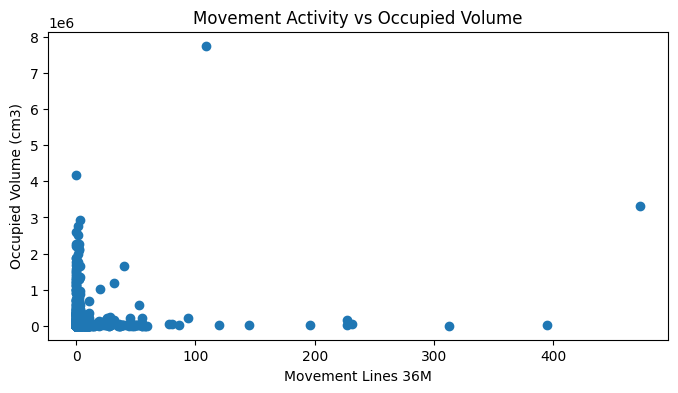

,Movement_Class,Parts,Total_Occupied_Volume,Avg_Unit_Volume,Total_Movement_Lines
0,A,9,8102613,74743.89,742
1,A+,8,3593676,10513.88,2207
2,B,59,7234162,9387.64,1965
3,C,167,9013510,6622.99,1001
4,D,338,57846937,38095.01,397
5,NC,419,55296193,44971.34,16


In [8]:
# Estimate occupied volume using current stock and unit volume
warehouse_profile["Total_Occupied_Volume_cm3"] = (
    warehouse_profile["Stock_Qty"] *
    warehouse_profile["Unit_Volume_cm3"]
)

volume_summary = (
    warehouse_profile
    .groupby("Movement_Class")
    .agg(
        Parts=("Part_ID", "count"),
        Total_Occupied_Volume=("Total_Occupied_Volume_cm3", "sum"),
        Avg_Unit_Volume=("Unit_Volume_cm3", "mean"),
        Total_Movement_Lines=("Movement_Lines_36M", "sum")
    )
    .round(2)
    .reset_index()
)

plt.figure(figsize=(8,4))

plt.scatter(
    warehouse_profile["Movement_Lines_36M"],
    warehouse_profile["Total_Occupied_Volume_cm3"]
)

plt.xlabel("Movement Lines 36M")
plt.ylabel("Occupied Volume (cm3)")
plt.title("Movement Activity vs Occupied Volume")

plt.show()

volume_summary

In [ ]:
location_summary.to_csv(OUTPUT_DIR / "warehouse_location_summary.csv", index=False)
udc_summary.to_csv(OUTPUT_DIR / "udc_summary.csv", index=False)
volume_summary.to_csv(OUTPUT_DIR / "warehouse_volume_summary.csv", index=False)

## Operational Observations

The warehouse structure analyses highlight several operational characteristics typical of industrial spare-parts environments.

The analyses show:
- concentration of warehouse activity within a limited subset of inventory items
- uneven warehouse-space utilisation across locations and storage structures
- significant dimensional variability across the spare-parts population
- coexistence of high-movement and high-volume inventory constraints
- operational relevance of UDC/container and handling structures
- storage-density optimisation opportunities within the current warehouse layout

The analyses also confirm that warehouse operational priorities cannot be evaluated exclusively through inventory value or demand behaviour.

Physical warehouse characteristics such as:
- item dimensions
- occupied volume
- movement intensity
- storage accessibility
- handling/container structure

play an important role in warehouse organisation and operational efficiency.

These results provide the operational foundation for the following automated warehouse feasibility and tray-allocation optimisation analyses.